<a href="https://colab.research.google.com/github/aalfonso500-code/Telecom-analysis/blob/main/telecom_analysis_project6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv") #completa el código
usage = pd.read_csv("/datasets/usage.csv") #completa el código

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos
print()
print(users.isna().sum() / len(users)) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum()) # Cantidad de valores nulos
print()
print(usage.isna().sum() / len(users)) # Proporción de valores nulos

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.0000
user_id     0.0000
type        0.0000
date        0.0125
duration    5.5190
length      4.4740
dtype: float64


✍️ **Comentario**:


Valores nulos en DF **users**:

- Col `city`: Cerca del 11% son nulos, se va buscar imputar tranto de encontrar patrones clave o dejarlos como nulos si es necesario.
- Col `churn_date`: Esta columna indica que el 88% de los clientes siguen vigentes y nos puede servir para obtener insight de abandono.  

Valores nulos en DF **usage**:

- Col `date`: Al ser menos del 2% se puede ignorar, pero hacer la observación al equipo para reducir o eliminar este sesgo en el futuro.
- Col `duration` y `lenght`: Esta dos columnas son complementarias si se suman se obtiene el 100% de los datos.


💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- En la columna `user_id` se observa que hay 4000 IDs consecutivos que van del 10000 al 13999
- En la columna `age` se observan sentinels (-999), se va buscar imputar para reducir alteraciones en las medidas descriptivas.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` un comportamiento normal al ser IDs.
- Las columnas `duration` y `length` se observa outliers ya que los maximos se alejan demasiado del 3Q.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for columna in columnas_user:
    print(f"\nDistribución de {columna}:")
    print(users[columna].value_counts(normalize= True))


Distribución de city:
Bogotá      0.228830
CDMX        0.206740
Medellín    0.174455
GDL         0.127443
Cali        0.120079
MTY         0.115265
?           0.027188
Name: city, dtype: float64

Distribución de plan:
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


- La columna `city` muestra que el 2 % de los datos son desconocidos y representados con "?".
- En la columna `plan` se observa que 64.8 % de los clientes tiene plan básico y el 35% premium.

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts(normalize= True)

text    0.5523
call    0.4477
Name: type, dtype: float64

- En la columna `type` vemos que 55% de las operaciones son por texto y el 45% por llamada.


---
✍️ **Comentario**:  

Se encontraron valores invalidos en las columnas `age` y `city`del df **users**.

Se va a buscar imputar en `age` los sentinels (-999) con la mediana para evitar que se distorcionen nuestros datos estadísticos.

En city se va por cambiara el caracter "?" por NaN.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors = "coerce")
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors = "coerce")
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [ ]:
# Revisar los años presentes en `reg_date` de users
users["year"] = users["reg_date"].dt.year
users["year"].value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: year, dtype: int64

En `reg_date` se encuentran 40 datos en el año 2026, el cual es un error ya que una fecha que aún no sucede.


In [ ]:
# Revisar los años presentes en `date` de usage
usage["year"] = usage["date"].dt.year
usage["year"].value_counts()

2024.0    39950
Name: year, dtype: int64

En `date`  casi todos los datos son del año **2024** a ecepción de 50 asi que; basaremos el análisis en este año.

✍️ **Comentario**:

Solo enfocaremos el análisis en el año **2024** debido a que solo se tiene información  de ese lapso en el DF **usage**.También vamos a omitir los errores hallados en el DF **users** ya que no corresponden al año a analizar, además de que son una cantidad mínimna inferior al 3%.



---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
## Reemplazar -999 por la mediana de age
# Contamos cuántas veces aparece el -999 antes de limpieza

conteo_sentinels_antes = (users['age'] == -999).sum()
print(f"Cantidad de valores -999 antes el cambio: {conteo_sentinels_antes}")


# Calculamos la mediana de la columna "age"
mediana_age = users['age'].median()
print(f"La mediana calculada con los sentinels (-999) es: {mediana_age}")

# Filtramos solo las edades válidas para calcular la mediana real
mediana_age_real = users[users['age'] != -999]['age'].median()


print(f"La mediana real calculada (sin contar los -999) es: {mediana_age_real}")

# Reemplazamos el valor centinela por la mediana calculada
users['age'] = users['age'].replace(-999, mediana_age_real)

# Contamos cuántas veces aparece el -999 ahora
conteo_sentinelas = (users['age'] == -999).sum()
print(f"Cantidad de valores -999 tras el cambio: {conteo_sentinelas}")

# Verificar cambios
users['age'].describe()

Cantidad de valores -999 antes el cambio: 55
La mediana calculada con los sentinels (-999) es: 47.0
La mediana real calculada (sin contar los -999) es: 48.0
Cantidad de valores -999 tras el cambio: 0


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)


# Verificar cambios
users["city"].value_counts(dropna=False)

# Contar valores incluyendo los NA
print("Distribución después del cambio:")
print(users["city"].value_counts(dropna=False))


Distribución después del cambio:
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:
# Marcar fechas futuras como NA para reg_date
users["reg_date"] = users["reg_date"].where(users["year"] <= 2024, pd.NA)

# Verificar cambios
users["reg_date"].value_counts(dropna=False)


NaN             40
1.712276e+18     1
1.642202e+18     1
1.673738e+18     1
1.666735e+18     1
                ..
1.679652e+18     1
1.646886e+18     1
1.660726e+18     1
1.709958e+18     1
1.647998e+18     1
Name: reg_date, Length: 3961, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration

print("Relación entre type y nulos en duration:")
print(pd.crosstab(usage['type'], usage['duration'].isna(), margins=True))


Relación entre type y nulos en duration:
duration  False   True    All
type                         
call      17908      0  17908
text         16  22076  22092
All       17924  22076  40000


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print("\nRelación entre type y nulos en length:")
print(pd.crosstab(usage['type'], usage['length'].isna(), margins=True))


Relación entre type y nulos en length:
length  False   True    All
type                       
call       12  17896  17908
text    22092      0  22092
All     22104  17896  40000


Los valores `duration` y `length` son nulos por diseño , no por error, ya que `duration` es para **call** y `length` es para **text**.  Se observa que hay algunas incoherencias en el regsitro de datos ya que algunas llamadas se registraron en `length` y viceversa, al ser menor al .1% de los datos se va a omitir y se notificara al equipo para evirtar futuros problemas.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    'is_text': 'sum',      # total de mensajes
    'is_call': 'sum',      # total de llamadas
    'duration': 'sum'      # total de minutos
}).reset_index()
# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_min_llamadas"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_min_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users, on=["user_id"], how="inner")
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_min_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date,year
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,1640995200000000000,Basico,NaN,2022
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,1641018857914478619,Basico,NaN,2022
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,1641042515828957239,Basico,NaN,2022
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,1641066173743435858,Premium,NaN,2022
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,1641089831657914478,Basico,NaN,2022


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
#Filtrar operaciones del 2024
user_profile_2024 = user_profile[user_profile["year"]== 2024].copy()

# Resumen estadístico de las columnas numéricas
user_profile_2024.describe()

,user_id,cant_mensajes,cant_llamadas,cant_min_llamadas,age,year
count,1330.000000,1330.000000,1330.000000,1330.000000,1330.000000,1330.0
mean,13332.699248,5.500000,4.557143,24.126669,48.425564,2024.0
std,384.969999,2.382293,2.140329,19.458620,17.962865,0.0
min,12666.000000,0.000000,0.000000,0.000000,18.000000,2024.0
25%,12999.250000,4.000000,3.000000,11.332500,33.000000,2024.0
50%,13333.500000,5.000000,4.000000,20.325000,48.000000,2024.0
75%,13665.750000,7.000000,6.000000,32.542500,64.000000,2024.0
max,13999.000000,16.000000,13.000000,155.690000,79.000000,2024.0


In [ ]:
# Distribución porcentual del tipo de plan
user_profile_2024["plan"].value_counts(normalize = True)

Basico     0.656391
Premium    0.343609
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

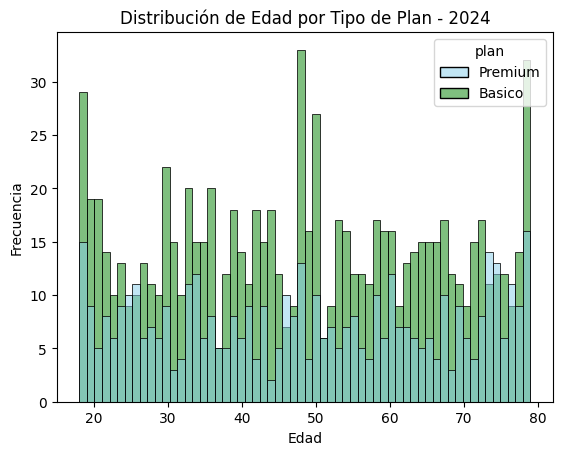

In [ ]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile_2024, x="age", hue="plan", bins=60, palette=['skyblue','green'])
plt.xlabel("Edad")
plt.ylabel("Frecuencia")  # Nota: era plt.Ylabel, debe ser plt.ylabel
plt.title("Distribución de Edad por Tipo de Plan - 2024")
plt.show()


💡Insights:

En la distribución se identifica una concentración atípica de clientes en el Plan Básico dentro del segmento de 45 a 55 años, con un pico máximo de frecuencia en los 48 años que triplica la adopción del Plan Premium en ese mismo punto.
Este segmento representa el mayor "volumen cautivo" de la empresa. La baja penetración del Plan Premium en un grupo demográfico que históricamente posee mayor estabilidad económica sugiere que el valor agregado del plan de alto costo no está siendo comunicado correctamente o no cubre sus necesidades específicas.

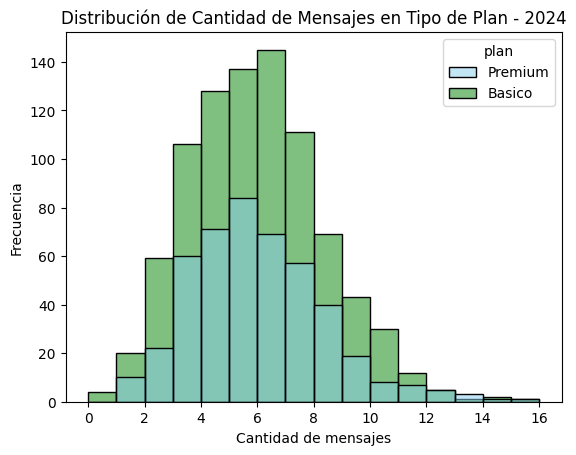

In [ ]:

# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile_2024, x="cant_mensajes", hue="plan", bins=16, palette=['skyblue','green'])
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")  # Nota: era plt.Ylabel, debe ser plt.ylabel
plt.title("Distribución de Cantidad de Mensajes en Tipo de Plan - 2024")
plt.show()



💡Insights:

Existe una superposición casi total en las curvas de distribución de ambos planes, con un comportamiento unimodal centrado en los 6 mensajes mensuales. Resulta crítico notar que incluso los usuarios del Plan Premium no muestran un uso intensivo, con una caída drástica en la frecuencia superando los 10 mensajes.

El servicio de mensajería ha dejado de ser un factor diferenciador de valor para ConnectaTel. Dado que el comportamiento de consumo es idéntico independientemente del precio pagado, mantener límites altos de SMS en el Plan Premium es una estrategia ineficaz. La empresa debería considerar reducir la relevancia de los SMS en su comunicación comercial y sustituir este "beneficio" por servicios de mayor demanda actual (como datos móviles o acceso a apps específicas), ya que el cliente Premium no está percibiendo un valor real por la capacidad adicional de mensajería que tiene disponible.

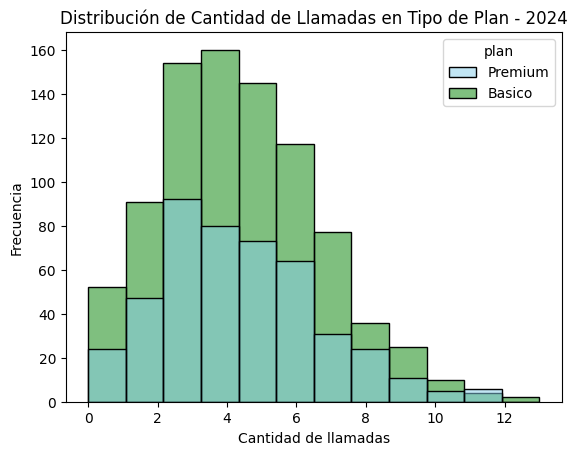

In [ ]:

# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile_2024, x="cant_llamadas", hue="plan", bins=12, palette=['skyblue','green'])
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")  # Nota: era plt.Ylabel, debe ser plt.ylabel
plt.title("Distribución de Cantidad de Llamadas en Tipo de Plan - 2024")
plt.show()




💡Insights:

El plan Básico concentra la mayor frecuencia de usuarios en los rangos medios de uso de llamadas, mientras que el plan Premium no muestra una diferencia significativa ni un mayor volumen en niveles altos de consumo.
El servicio de llamadas no está generando una diferenciación clara entre planes, lo que indica que el plan Premium no está capturando usuarios de alto consumo. Esto representa una oportunidad para rediseñar los beneficios del plan Premium o ajustar la estructura de precios para incentivar su adopción entre usuarios con mayor uso.

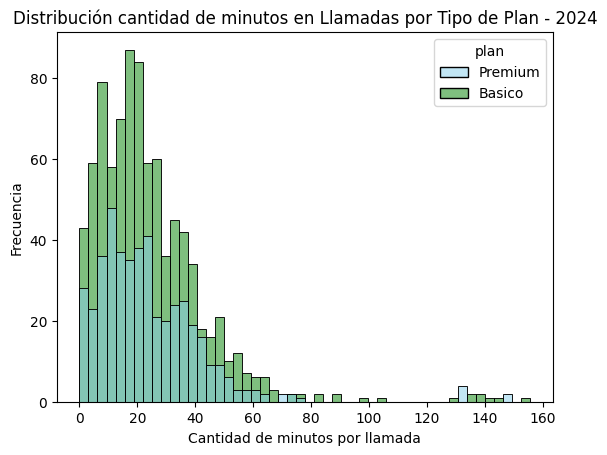

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile_2024, x="cant_min_llamadas", hue="plan", bins=50, palette=['skyblue','green'])
plt.xlabel("Cantidad de minutos por llamada")
plt.ylabel("Frecuencia")  # Nota: era plt.Ylabel, debe ser plt.ylabel
plt.title("Distribución cantidad de minutos en Llamadas por Tipo de Plan - 2024")
plt.show()


💡Insights:

Mientras que el 85% de la base (tanto Básico como Premium) mantiene un consumo moderado por debajo de los 40 minutos, se identifica un grupo crítico de "valores atípicos" que superan los 130 minutos. Sorprendentemente, varios de estos usuarios de alto consumo pertenecen al Plan Básico, generando un uso de red desproporcionado respecto a su pago mensual.
Estos usuarios "outliers" en el Plan Básico representan un riesgo para el margen operativo de la empresa, ya que consumen recursos de infraestructura similares a un usuario Premium pero con una contribución menor.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

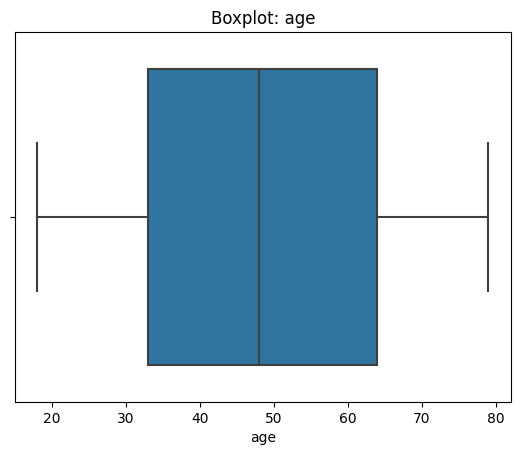

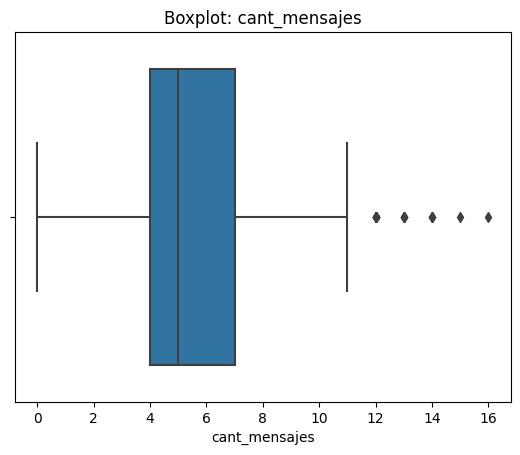

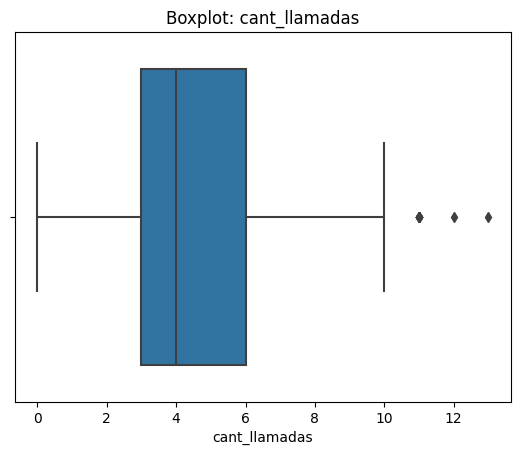

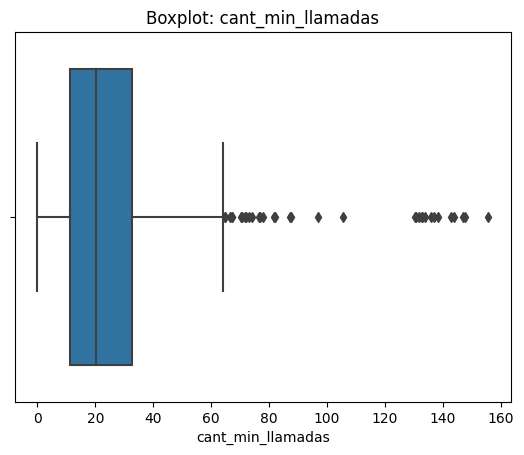

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_min_llamadas']

for col in columnas_numericas:
    sns.boxplot(data=user_profile_2024, x= col,  )
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: No presenta outliers
- cant_mensajes: Si presenta outliers.Cualquier usuario con más de 12 mensajes es una anomalía estadística.
- cant_llamadas: Si presenta outliers.Cualquier usuario con más de 10 llamadas es una anomalía estadística.
- cant_min_llamadas: Es donde se puede apreciar las mayor cantidad outliers.Cualquier usuario con más de 60 minutos por llamada es una anomalía estadística.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_min_llamadas"]

for col in columnas_limites:
    Q1 = user_profile_2024[col].quantile(0.25)
    Q3 = user_profile_2024[col].quantile(0.75)
    RIQ = Q3 - Q1
    RI = Q1 - (1.5 * RIQ)
    RS = Q3 + (1.5 * RIQ)

    print(f"El rango superior de {col}: {RS}")
    print()  # línea en blanco para separar cada columna



El rango superior de cant_mensajes: 11.5

El rango superior de cant_llamadas: 10.5

El rango superior de cant_min_llamadas: 64.35749999999999



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile_2024[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_min_llamadas
count,1330.000000,1330.000000,1330.000000
mean,5.500000,4.557143,24.126669
std,2.382293,2.140329,19.458620
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.332500
50%,5.000000,4.000000,20.325000
75%,7.000000,6.000000,32.542500
max,16.000000,13.000000,155.690000


💡Insights:

En ningun caso se deben de elimnar los outliers ya que son compartimentos reales de los consumidores y borrarlos nos segarias de la realidad. En el caso de la cantidad de llamadas y mensajes los outliers son muy pocos (menos del 3%), debido a esto no distorcionan las medidas estadisticas. Por otro lado el límite estadístico superior de la duracion de llamadas es de 64 minutos, existe un 5% de la población que consume hasta 155 minutos mensuales. Este grupo de outliers debe ser analizado como un segmento de 'Alto Consumo' para estrategias de retención personalizadas y no sesgen el analisis del comportamiento normal de los otros usuraios.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_uso(llamadas, mensajes):
    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"
    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"
    else:
        return "Alto uso"

# Aplicar la función
user_profile_2024["grupo_uso"] = user_profile_2024.apply(
    lambda row: clasificar_uso(row["cant_llamadas"], row["cant_mensajes"]),
    axis=1
)


In [ ]:
# verificar cambios
user_profile_2024.head()

,user_id,cant_mensajes,cant_llamadas,cant_min_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date,year,grupo_uso
2665,12666,13,3,11.50,Mateo,Garcia,20.0,Cali,1704067200000000000,Premium,NaN,2024,Alto uso
2666,12667,3,7,33.27,Carlos,Gomez,72.0,Cali,1704090857914478624,Premium,NaN,2024,Uso medio
2667,12668,5,7,87.56,Ana,Torres,21.0,CDMX,1704114515828957240,Basico,NaN,2024,Uso medio
2668,12669,4,5,27.62,Sofia,Garcia,58.0,CDMX,1704138173743435864,Basico,NaN,2024,Uso medio
2669,12670,9,4,31.90,Ana,Garcia,54.0,MTY,1704161831657914480,Premium,NaN,2024,Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(edad):
    if edad < 30 :
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto_Mayor"

# Aplicar la función
user_profile_2024["grupo_edad"] = user_profile_2024.apply(
    lambda row: clasificar_edad(row["age"]),
    axis=1
)

In [ ]:
# verificar cambios
user_profile_2024.head()

,user_id,cant_mensajes,cant_llamadas,cant_min_llamadas,first_name,last_name,age,city,reg_date,plan,churn_date,year,grupo_uso,grupo_edad
2665,12666,13,3,11.50,Mateo,Garcia,20.0,Cali,1704067200000000000,Premium,NaN,2024,Alto uso,Joven
2666,12667,3,7,33.27,Carlos,Gomez,72.0,Cali,1704090857914478624,Premium,NaN,2024,Uso medio,Adulto_Mayor
2667,12668,5,7,87.56,Ana,Torres,21.0,CDMX,1704114515828957240,Basico,NaN,2024,Uso medio,Joven
2668,12669,4,5,27.62,Sofia,Garcia,58.0,CDMX,1704138173743435864,Basico,NaN,2024,Uso medio,Adulto
2669,12670,9,4,31.90,Ana,Garcia,54.0,MTY,1704161831657914480,Premium,NaN,2024,Uso medio,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

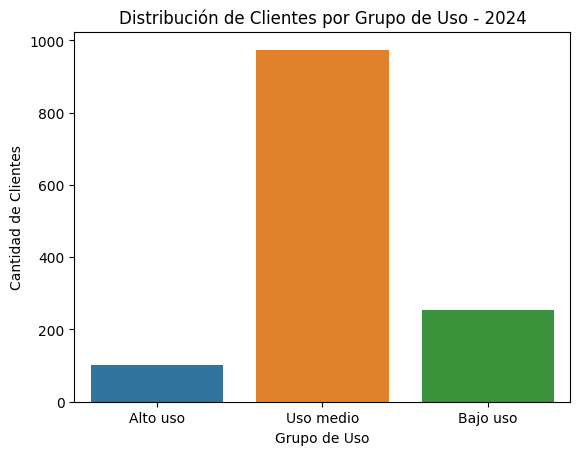

Uso medio    0.732331
Bajo uso     0.191729
Alto uso     0.075940
Name: grupo_uso, dtype: float64

In [ ]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile_2024, x='grupo_uso')
plt.title('Distribución de Clientes por Grupo de Uso - 2024')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Clientes')
plt.show()
user_profile_2024["grupo_uso"].value_counts(normalize = True)


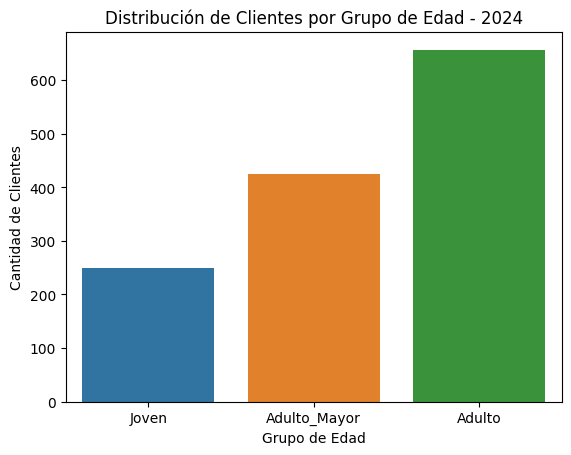

Adulto          0.493985
Adulto_Mayor    0.318797
Joven           0.187218
Name: grupo_edad, dtype: float64

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile_2024, x='grupo_edad')
plt.title('Distribución de Clientes por Grupo de Edad - 2024')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Clientes')
plt.show()
user_profile_2024["grupo_edad"].value_counts(normalize = True)

In [ ]:
# Cruzamos las dos variables para ver la distribución
matriz_uso_edad = pd.crosstab(user_profile_2024['grupo_edad'],
                              user_profile_2024['grupo_uso'],
                              normalize='index') * 100

print("Porcentaje de nivel de uso por cada rango de edad:")
print(matriz_uso_edad)

Porcentaje de nivel de uso por cada rango de edad:
grupo_uso     Alto uso   Bajo uso  Uso medio
grupo_edad                                  
Adulto        7.305936  18.873668  73.820396
Adulto_Mayor  7.075472  21.933962  70.990566
Joven         9.236948  15.261044  75.502008


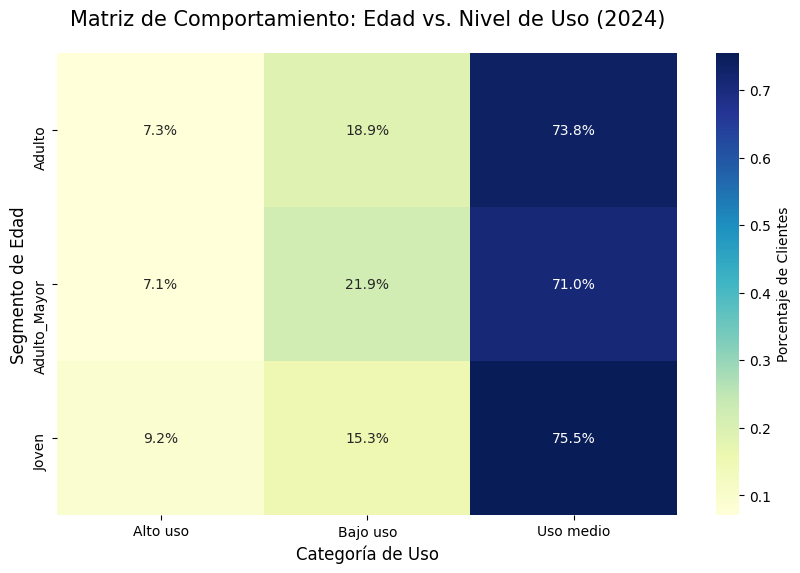

In [ ]:
#Gráfico de analisis cruzado
# 1. Preparar los datos (Cruce de frecuencias)
ct = pd.crosstab(user_profile_2024['grupo_edad'],
                 user_profile_2024['grupo_uso'],
                 normalize='index')

# 2. Configurar el estilo
plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, cmap="YlGnBu", fmt=".1%", cbar_kws={'label': 'Porcentaje de Clientes'})

# 3. Detalles estéticos
plt.title('Matriz de Comportamiento: Edad vs. Nivel de Uso (2024)', fontsize=15, pad=20)
plt.ylabel('Segmento de Edad', fontsize=12)
plt.xlabel('Categoría de Uso', fontsize=12)
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Valores nulos en DF **users**:

- Col `city`:  ≈ 11% tenian sentinels "?", se convirtieron a NaN.
- Col `churn_date`: El 88% son ausentes indicando que el cliente sigue viegente.

Valores nulos en DF **usage**:

- Col `date`: El 2% de los datos estaban en fechas erroneas correspondientes al año 2026 (aun no ocurrian), no se tomaron a consideración.
- Col `duration` y `lenght`: Esta dos columnas son complementarias si se suman se obtiene el 100% de los datos.


🔍 **Segmentos por Edad**
- El perfil del cliente actual está fuertemente inclinado hacia la madurez (81.3%). Casi la mitad de la base de datos (49.4%) son Adultos, seguidos por un 31.9% de Adultos Mayores.
- Baja penetración en el mercado joven: Con solo un 18.7%, el segmento "Joven" es el menos representado. Esto indica una posible brecha en la relevancia de la marca para las nuevas generaciones o una barrera de entrada (precio, lenguaje, canales digitales).

📊 **Segmentos por Nivel de Uso**
- El 73.2% de tus clientes se encuentra en la categoría de Uso Medio.Es una base de clientes sumamente homogénea. No son usuarios "pesados" que saturen la red, pero tampoco son usuarios inactivos. Esto es ideal para la estabilidad de ingresos, ya que no se depende de unos pocos clientes de alto consumo, sino de una gran masa crítica.
-
- Se detectaron ouliers importantes en el duración de llamadas, cerca del 5% de los ususrios  exceden por hasta por 90 minutos  el comportamiento normal del usurio(60 min como max). Se recomienda profundizar en este segmento de clientes para conocerlos mejor y destacar posible fraude donde se usen lineas residencias operando como call centers, cualquier caso poder presentarle propuestas más atractivas a sus necesidades.


➡️ Esto sugiere que

- El grupo Adulto es el "Cash Cow". Las decisiones de diseño de producto deben priorizar la facilidad de uso y la eficiencia para este grupo, ya que representan casi el 50% del ingresos potenciales.
- Propuesta de Valor Desfasada: ConnectaTel resuena con un público que busca estabilidad y madurez, pero está perdiendo la carrera por el mercado joven.
- Eficiencia de Red: La homogeneidad del 73.2% (Uso Medio) permite una planificación de infraestructura muy eficiente, ya que no hay una volatilidad extrema en la demanda masiva.
-Barreras de Entrada: La baja penetración joven sugiere que el lenguaje de la marca y el empaquetado de "llamadas/mensajes" actúa como una barrera frente a competidores que venden "experiencias digitales".


💡 **Recomendaciones**
-Creación del "Plan Connecta-Z": Un plan diseñado para el 18.7% joven donde los minutos y mensajes no utilizados se convierten automáticamente en GB de navegación al final del mes. Esto aumenta la percepción de valor sin aumentar el costo real.

-Estrategia "Familia Connecta": Aprovechar el 81% de adultos/mayores para crear planes donde el titular (Adulto) pueda "heredar" o compartir sus beneficios con familiares jóvenes, anclando a todo el grupo familiar a la compañía.

-Optimización de Retención: Para el 19.2% de Bajo Uso, implementar un programa de lealtad basado en la permanencia (años con la empresa) y no en el volumen de consumo, para evitar que migren a la competencia por precio.

-Realizar un estudio de los outliers en duracion de llamadas para conocer causas y necesidades, para asi poder ofrecer un plan que se adapte mejor a ese nicho de mercado.



---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`